<a href="https://colab.research.google.com/github/AnuskaDey07/Pixora/blob/feature%2Fobject_detection/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 7.8 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("Object Detection model loaded!")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Object Detection model loaded!


Saving MN-Tamarack-Park-100.avif to MN-Tamarack-Park-100.avif

image 1/1 /content/MN-Tamarack-Park-100.avif: 736x1280 14 persons, 1 bicycle, 1 bench, 19.3ms
Speed: 4.6ms preprocess, 19.3ms inference, 1.8ms postprocess per image at shape (1, 3, 736, 1280)


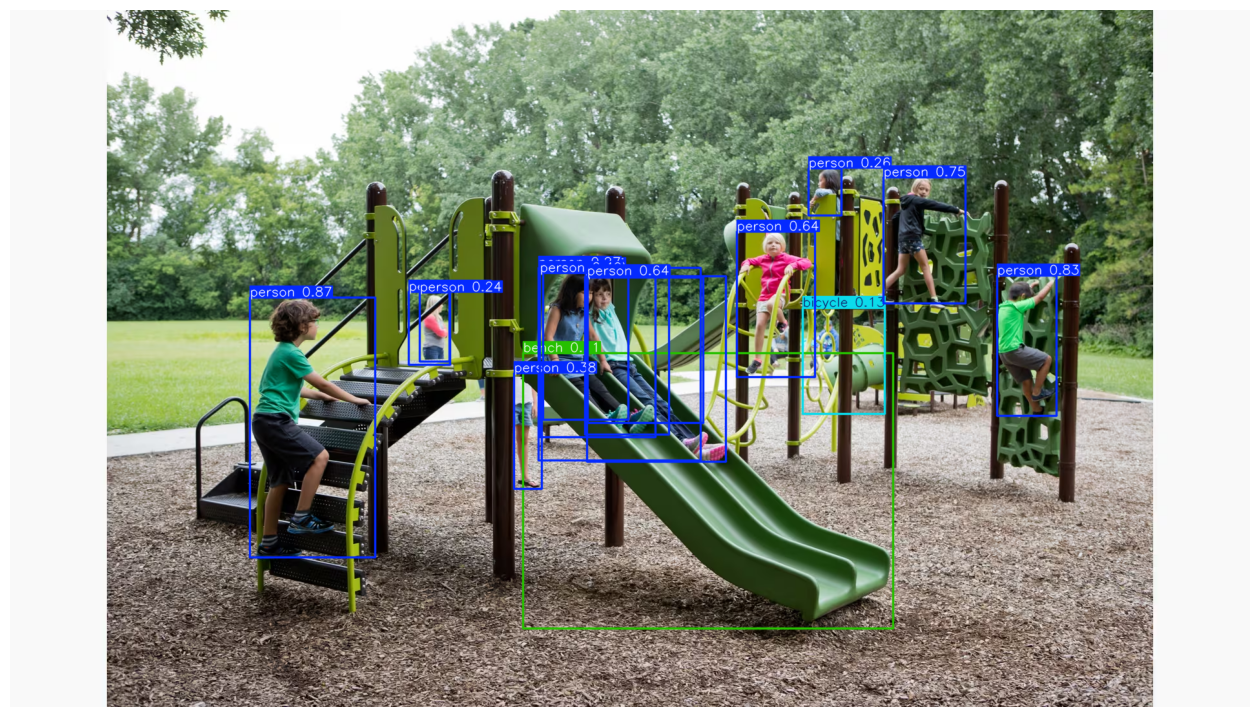

In [23]:
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))

results = model.predict(
    source=image_path,
    conf=0.10,
    iou=0.7,
    imgsz=1280,
    max_det=300,
    verbose=True
)

# Get the detected image with smaller labels and boxes
annotated_image = results[0].plot(
    font_size=0.7,
    line_width=2
)

# Display the result
plt.figure(figsize=(16, 10))
plt.imshow(annotated_image[:, :, ::-1])  # BGR to RGB
plt.axis("off")
plt.show()

In [24]:

import pandas as pd

result = results[0]
boxes = result.boxes

detections = []

for box in boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    detections.append({
        "Object": result.names[class_id],
        "Confidence": round(confidence, 3),
        "X1": round(x1, 1),
        "Y1": round(y1, 1),
        "X2": round(x2, 1),
        "Y2": round(y2, 1)
    })

df = pd.DataFrame(detections)
display(df)


,Object,Confidence,X1,Y1,X2,Y2
0,person,0.869,371.1,446.8,565.8,848.1
1,person,0.826,1528.5,412.6,1620.2,629.6
2,person,0.749,1352.8,260.2,1479.6,455.1
3,person,0.639,1125.3,345.0,1246.6,569.4
4,person,0.635,893.3,413.4,1108.9,700.3
5,person,0.493,820.3,408.3,999.3,662.2
6,person,0.376,780.2,563.8,823.4,742.0
7,person,0.268,818.6,400.9,1069.5,698.9
8,person,0.256,1236.6,246.2,1287.2,319.4
9,person,0.243,634.3,438.3,680.1,545.7


Total detections: 12
Saved image: outputs/MN-Tamarack-Park-100_detected.jpg


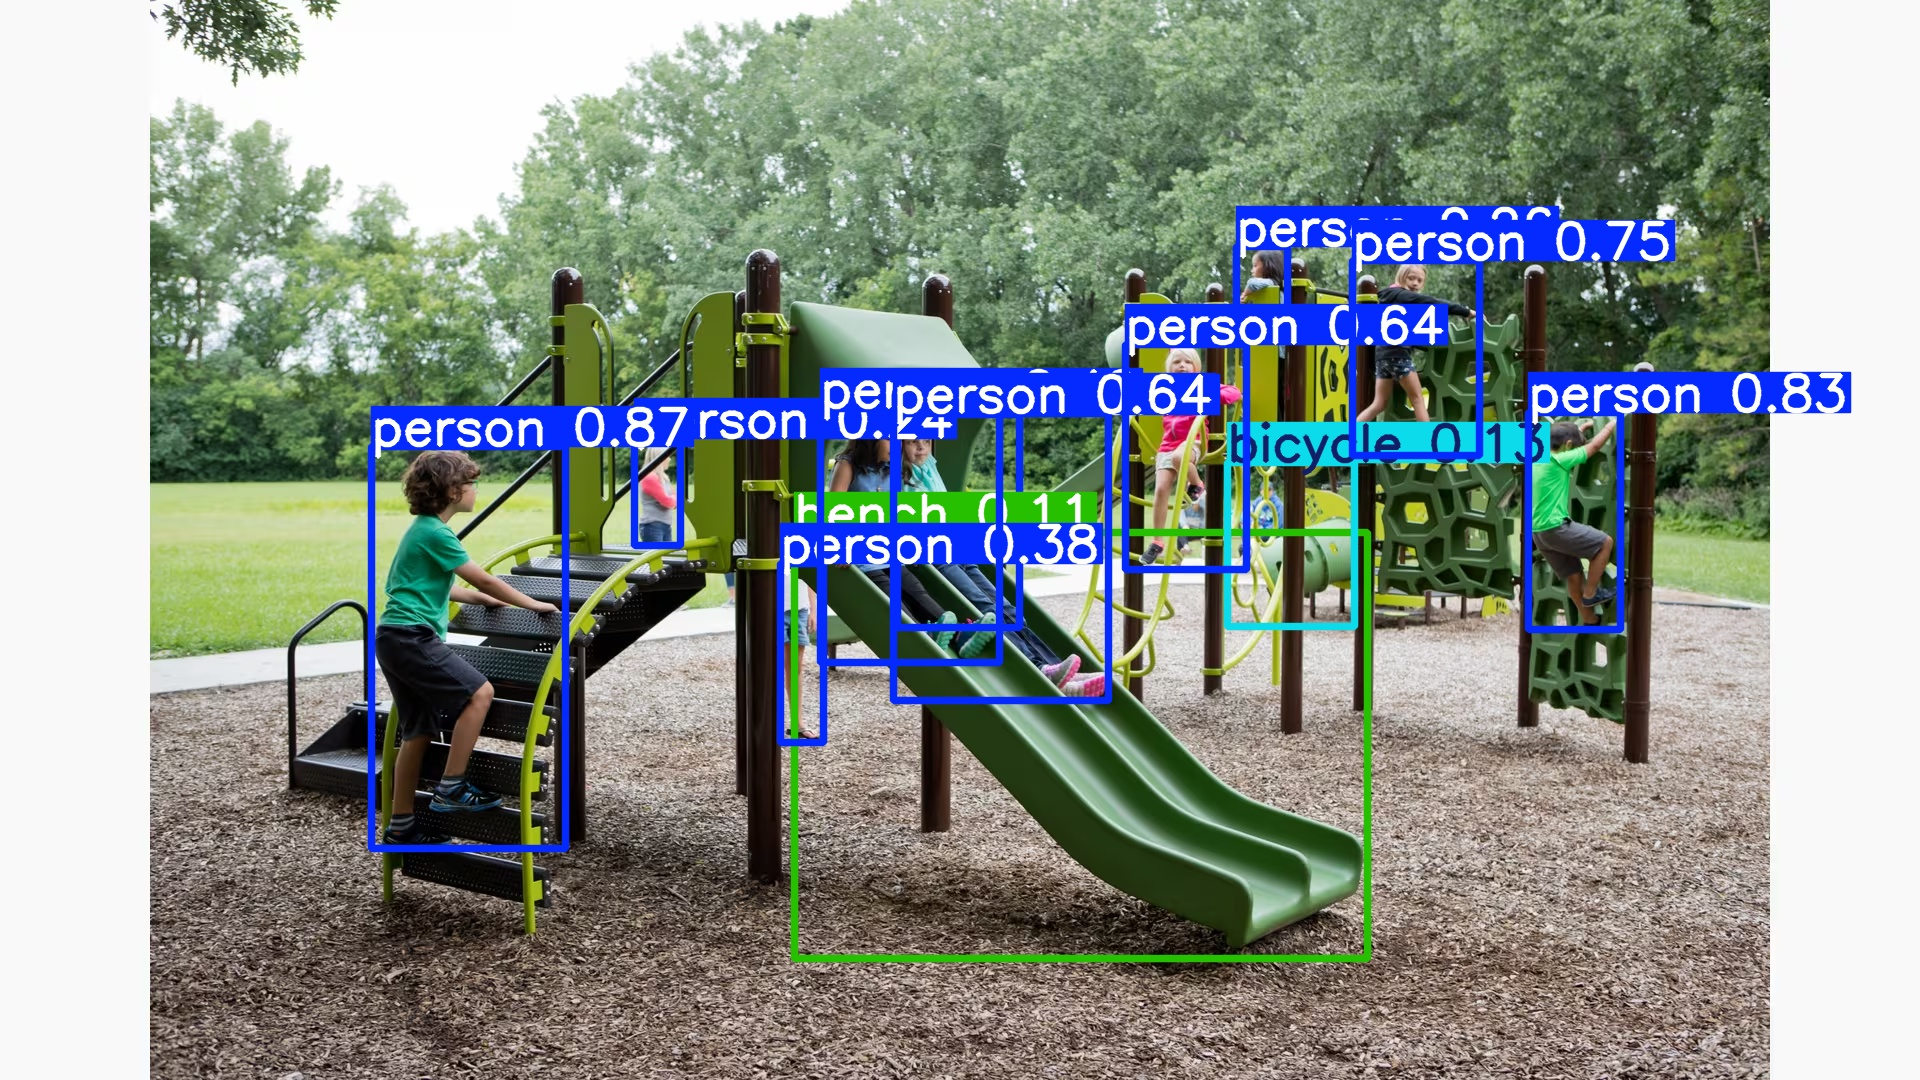

,Object,Confidence,x1,y1,x2,y2
0,person,0.8694,371.06,446.78,565.83,848.14
1,person,0.8262,1528.47,412.60,1620.19,629.63
2,person,0.7494,1352.83,260.19,1479.58,455.11
3,person,0.6387,1125.26,344.96,1246.63,569.41
4,person,0.6354,893.30,413.38,1108.93,700.29
5,person,0.4928,820.26,408.25,999.34,662.21
6,person,0.3764,780.17,563.84,823.43,742.03
7,person,0.2557,1236.60,246.16,1287.19,319.41
8,person,0.2428,634.31,438.31,680.13,545.74
9,bicycle,0.1259,1227.73,462.60,1354.15,626.88


In [26]:

from object_detection import detect_objects
from IPython.display import display, Image
import pandas as pd

output = detect_objects(
    image_path=image_path,
    confidence=0.10,
    image_size=1280,
    iou=0.5,
)

print("Total detections:", output["total_detections"])
print("Saved image:", output["annotated_image"])

display(Image(filename=output["annotated_image"]))

df = pd.DataFrame([
    {
        "Object": item["label"],
        "Confidence": item["confidence"],
        **item["bbox"],
    }
    for item in output["detections"]
])

display(df)


In [19]:
%%writefile requirements.txt
ultralytics
opencv-python-headless
pandas

Writing requirements.txt


In [20]:

%%writefile object_detection.py

from pathlib import Path
from ultralytics import YOLO
import cv2

def detect_objects(
    image_path,
    output_dir="outputs",
    confidence=0.25,
    image_size=1280,
    iou=0.5,
    model=None
):
    image_path = Path(image_path)

    if not image_path.is_file():
        raise FileNotFoundError(f"Image not found: {image_path}")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if model is None:
        model = YOLO("yolo26n.pt")

    result = model.predict(
        source=str(image_path),
        conf=confidence,
        imgsz=image_size,
        iou=iou,
        verbose=False
    )[0]

    output_path = output_dir / f"{image_path.stem}_detected.jpg"

    if not cv2.imwrite(str(output_path), result.plot()):
        raise OSError("Could not save annotated image")

    detections = []

    for box in result.boxes:
        class_id = int(box.cls[0].item())
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        detections.append({
            "label": result.names[class_id],
            "confidence": round(float(box.conf[0].item()), 4),
            "bbox": {
                "x1": round(x1, 2),
                "y1": round(y1, 2),
                "x2": round(x2, 2),
                "y2": round(y2, 2)
            }
        })

    height, width = result.orig_shape

    return {
        "annotated_image": str(output_path),
        "image_width": width,
        "image_height": height,
        "total_detections": len(detections),
        "detections": detections
    }


Writing object_detection.py
